In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tqdm

res = 50

# Construct filter
max_freq = 3
min_freq = 0
x, y = np.meshgrid(np.arange(res), np.arange(res))
r = np.sqrt((x-res//2)**2 + (y-res//2)**2)
filt = np.greater(max_freq - r, 0) * np.greater(r-min_freq,0)

# Make random noise patterns
N = 4096
noise = np.random.randn(N, res, res)

# Convolve with filter
noise_tilde = np.fft.fftshift(np.fft.fft2(noise))
noise_tilde_filt = noise_tilde * filt
patterns = np.real(np.fft.ifft2(np.fft.ifftshift(noise_tilde_filt)))

In [2]:
# Fourier transform 
rm_fft_real = np.zeros([N,res,res])
rm_fft_imag = np.zeros([N,res,res])

for i in tqdm.tqdm(range(N)):
    rm_fft_real[i] = np.real(np.fft.fft2(patterns[i].reshape([res,res])))
    rm_fft_imag[i] = np.imag(np.fft.fft2(patterns[i].reshape([res,res])))
    
rm_fft = rm_fft_real + 1j * rm_fft_imag

100%|██████████| 4096/4096 [00:00<00:00, 20236.73it/s]


In [3]:
k1 = [3,0]
k2 = [2,3]
k3 = [-1,3]
k4=k5=k6=k1

freq = 1
ks = freq*np.array([k1,k2,k3,k4,k5,k6])
ks = ks.astype('int')

modes = np.stack([rm_fft[:,k[0],k[1]] for k in ks])
# Find phases
phases = [np.angle(mode) for mode in modes]

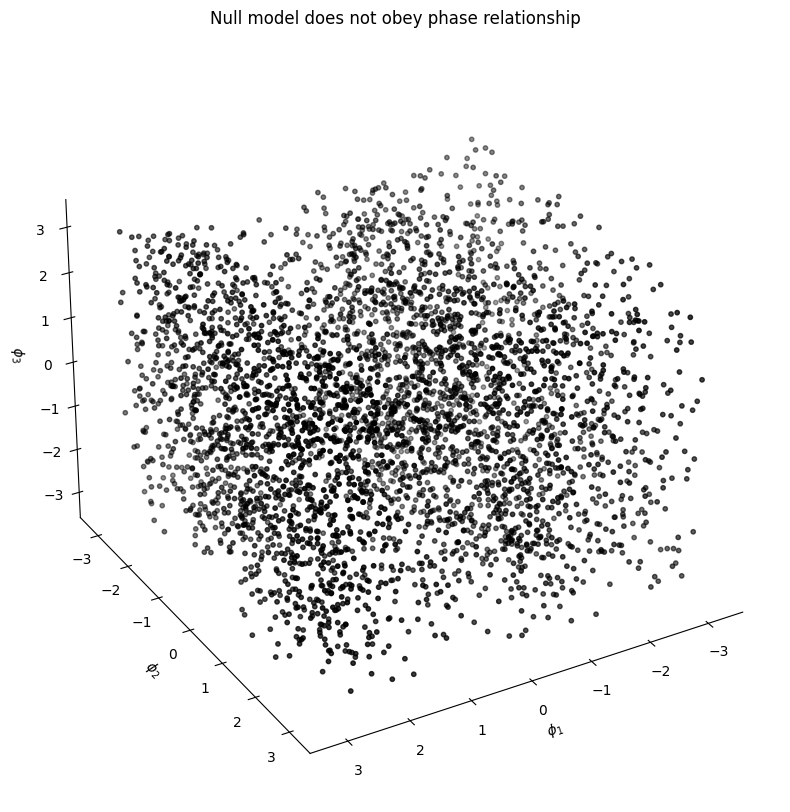

In [4]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(phases[0], phases[1], phases[2], c='black', s=10)
ax.view_init(azim=60)
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.xaxis._axinfo["grid"]['color'] =  (1,1,1,0)
ax.yaxis._axinfo["grid"]['color'] =  (1,1,1,0)
ax.zaxis._axinfo["grid"]['color'] =  (1,1,1,0)
ax.set_xlabel(r'$\phi_1$')
ax.set_ylabel(r'$\phi_2$')
ax.set_zlabel(r'$\phi_3$')
plt.title('Null model does not obey phase relationship');

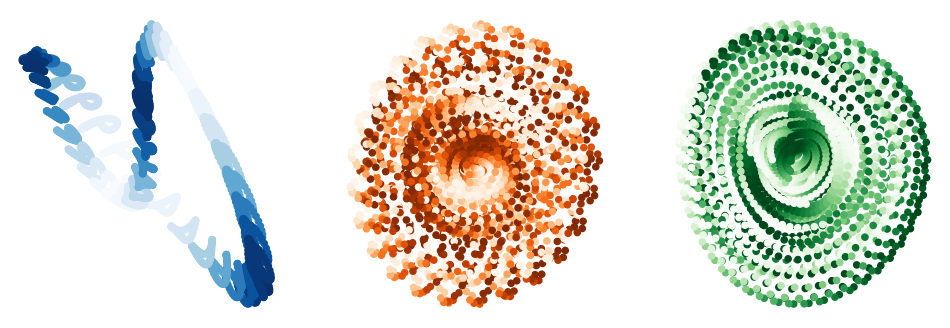

In [5]:
crop = 0
freq = 1
x = np.mgrid[:res,:res] * 2*np.pi/ res
x = x.reshape(2, -1)
k = freq*np.stack([k1,k2,k3])
X = np.concatenate([np.cos(k.dot(x)), np.sin(k.dot(x))], axis=0)
idxs1, idxs2 = np.mgrid[crop:res-crop, crop:res-crop]
idxs = np.ravel_multi_index((idxs1,idxs2), (res,res)).ravel()

cmaps = ['Blues', 'Oranges', 'Greens']

plt.figure(figsize=(12,4))
for i in range(3):
    plt.subplot(1,3,i+1)
    B = np.stack([np.cos(phases[i]), np.sin(phases[i])])
    test = B@patterns.reshape(N,-1)
    plt.scatter(test[0], test[1], c=X[i][idxs], cmap=cmaps[i], s=20)
    plt.axis('off')

In [6]:
import sys
sys.path.append('../grid_pattern_formation/utils')

import scipy
from two_d_sort import get_2d_sort

N = patterns.shape[0]
res = patterns.shape[1]
pattern_flat = patterns.reshape(N, -1)
pattern_centered = pattern_flat - pattern_flat.mean(axis=1, keepdims=True)

J_lp = (pattern_centered @ pattern_centered.T) / pattern_centered.shape[1]
print("Low-pass connectivity shape:", J_lp.shape)

Low-pass connectivity shape: (4096, 4096)


In [7]:
Ng = N
n = int(np.sqrt(Ng))

width = n
freq = 1
X, Y = np.meshgrid(np.arange(width), np.arange(width))
X = X * 2 * np.pi / width
Y = Y * 2 * np.pi / width

s1 = np.zeros(phases[0].shape)
s2 = np.zeros(phases[0].shape)
fac = np.sqrt(3) / 2

for i in range(Ng):
    penalty_1 = np.cos(freq * X - phases[0][i] / fac)
    penalty_2 = np.cos(freq * Y - phases[2][i] / fac)
    penalty_3 = np.cos(freq * (X + Y) - phases[1][i] / fac)
    ind = np.argmax(penalty_1 + penalty_2 + penalty_3 + np.random.randn() / 100)
    s1[i], s2[i] = np.unravel_index([ind], penalty_1.shape)

total_order = get_2d_sort(s1, s2)
print("Computed low-pass sort order with shape:", total_order.shape)

/var/folders/xr/w5s2z0_53_72lz946wg1nsmm0000gn/T/com.apple.shortcuts.mac-helper/ipykernel_7444/789384977.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  s1[i], s2[i] = np.unravel_index([ind], penalty_1.shape)


Computed low-pass sort order with shape: (4096,)


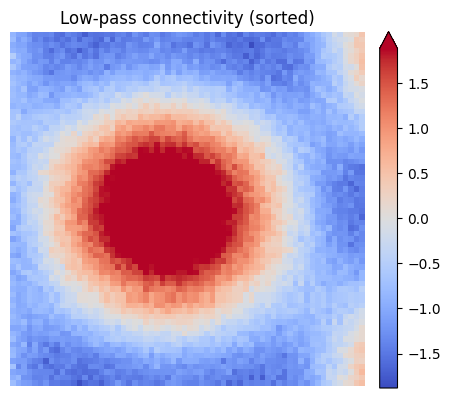

In [8]:
Jsort = J_lp[total_order][:, total_order]
J_square = np.reshape(Jsort, (n, n, n, n))

Jmean = np.zeros([n, n])
for i in range(n):
    for j in range(n):
        Jmean += np.roll(np.roll(J_square[i, j], -i, axis=0), -j, axis=1)

Jmean[0, 0] = np.max(Jmean[1:, 1:])
Jmean = np.roll(np.roll(Jmean, n // 2, axis=0), n // 2, axis=1)

A = np.asarray([[2, 1], [0, np.sqrt(3)]]) / 2
Ainv = np.linalg.inv(A)
im = scipy.ndimage.affine_transform(Jmean, Ainv, mode='wrap')
imroll = np.roll(np.roll(im, -n // 4, axis=0), 0, axis=1)

limit = abs(imroll.min())

plt.figure(figsize=(5, 5))
img = plt.imshow(imroll, cmap='coolwarm', vmin=-limit, vmax=limit)
plt.colorbar(img, fraction=0.046, pad=0.04, extend="max")
plt.title('Low-pass connectivity (sorted)')
plt.axis('off')

Jmean_lp_sorted = Jmean

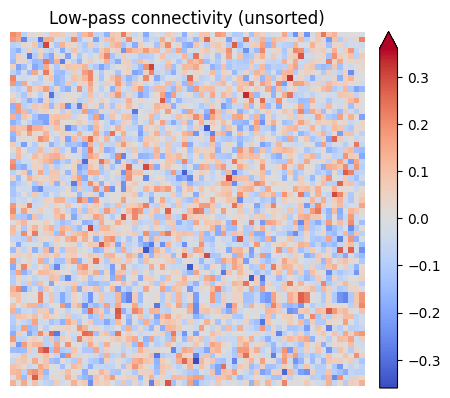

In [9]:
J_square_unsorted = np.reshape(J_lp, (n, n, n, n))

Jmean_unsorted = np.zeros([n, n])
for i in range(n):
    for j in range(n):
        Jmean_unsorted += np.roll(np.roll(J_square_unsorted[i, j], -i, axis=0), -j, axis=1)

Jmean_unsorted[0, 0] = np.max(Jmean_unsorted[1:, 1:])
Jmean_unsorted = np.roll(np.roll(Jmean_unsorted, n // 2, axis=0), n // 2, axis=1)

im_unsorted = scipy.ndimage.affine_transform(Jmean_unsorted, Ainv, mode='wrap')
imroll_unsorted = np.roll(np.roll(im_unsorted, -n // 4, axis=0), 0, axis=1)

limit = abs(imroll_unsorted.min())

plt.figure(figsize=(5, 5))
img = plt.imshow(imroll_unsorted, cmap='coolwarm', vmin=-limit, vmax=limit)
plt.colorbar(img, fraction=0.046, pad=0.04, extend="max")
plt.title('Low-pass connectivity (unsorted)')
plt.axis('off')

Jmean_lp_unsorted = Jmean_unsorted

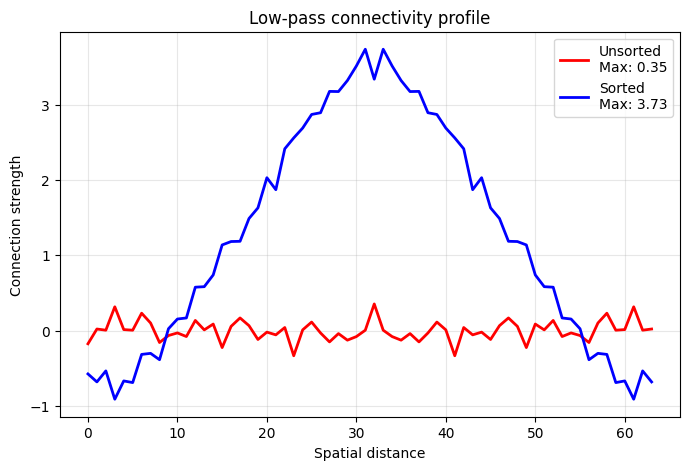

In [10]:
mid = n // 2
slice_unsorted = Jmean_lp_unsorted[mid, :]
slice_sorted = Jmean_lp_sorted[mid, :]

plt.figure(figsize=(8, 5))
plt.plot(slice_unsorted, label=f'Unsorted\nMax: {slice_unsorted.max():.2f}', color='red', linewidth=2)
plt.plot(slice_sorted, label=f'Sorted\nMax: {slice_sorted.max():.2f}', color='blue', linewidth=2)
plt.title('Low-pass connectivity profile')
plt.xlabel('Spatial distance')
plt.ylabel('Connection strength')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
import scipy
import scipy.ndimage
import torch
from tqdm import tqdm

from grid_pattern_formation.evals.core import build_eval_context, get_cached_ratemaps
from grid_pattern_formation.evals.analysis_connectivity import _compute_phase_order, _compute_jmean, _compute_phase_original_order
from grid_pattern_formation.evals.analysis_dynamics import get_fourier_spectrum, find_peak_coordinates
from grid_pattern_formation.evals.analysis_core import compute_grid_scores
from grid_pattern_formation.utils.two_d_sort import get_2d_sort

%matplotlib inline

plt.rcParams.update({
    "figure.dpi": 150,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 10,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.bbox": "tight",
    "savefig.dpi": 300,
})

baseline_ctx = build_eval_context(
    checkpoint_path="../checkpoints/replicate_baseline_colab_orig_rmsprop_alive.pth",
    config_path="../configs/replicate_baseline_colab_orig_rmsprop_alive.yaml",
    results_root="../results/phase_analysis",
)
topo_ctx = build_eval_context(
    checkpoint_path="../checkpoints/cos_decay_hw4_final_model.pth",
    config_path="../configs/topo_cos_decay_hw4.yaml",
    results_root="../results/phase_analysis",
)

RES = 50
N_AVG = 100
Ng = 4096
n = int(np.sqrt(Ng))

print("Baseline ratemaps")
baseline_act, baseline_rm, baseline_g, baseline_pos = get_cached_ratemaps(baseline_ctx, res=RES, n_avg=N_AVG, ng=Ng)
print("Topoloss ratemaps")
topo_act, topo_rm, topo_g, topo_pos = get_cached_ratemaps(topo_ctx, res=RES, n_avg=N_AVG, ng=Ng)

baseline_order, baseline_phases = _compute_phase_order(baseline_ctx, baseline_rm, RES)
topo_order, topo_phases = _compute_phase_original_order(topo_ctx, topo_rm, RES)

J_baseline = baseline_ctx.model.RNN.weight_hh_l0.detach().cpu().numpy().T
J_topo = topo_ctx.model.RNN.weight_hh_l0.detach().cpu().numpy().T

J_baseline_sorted = J_baseline[baseline_order][:, baseline_order]

_, baseline_imroll_sorted = _compute_jmean(J_baseline_sorted, n)
_, baseline_imroll_unsorted = _compute_jmean(J_baseline, n)
_, topo_imroll_unsorted = _compute_jmean(J_topo, n)

print("Baseline grid scores")
baseline_scores = compute_grid_scores(baseline_ctx)
print("Topoloss grid scores")
topo_scores = compute_grid_scores(topo_ctx)

Baseline ratemaps
Topoloss ratemaps
Baseline grid scores


Grid scores:   0%|          | 0/4096 [00:00<?, ?it/s]/Volumes/LaCie SSD/Documents/MurtyLab/grid-pattern-formation/grid_pattern_formation/evals/grid_scores.py:115: RuntimeWarning: invalid value encountered in divide
  x_coef = np.divide(covar, np.multiply(std_seq1, std_seq2))
Grid scores: 100%|██████████| 4096/4096 [00:12<00:00, 328.13it/s]


Topoloss grid scores


Grid scores: 100%|██████████| 4096/4096 [00:12<00:00, 334.36it/s]


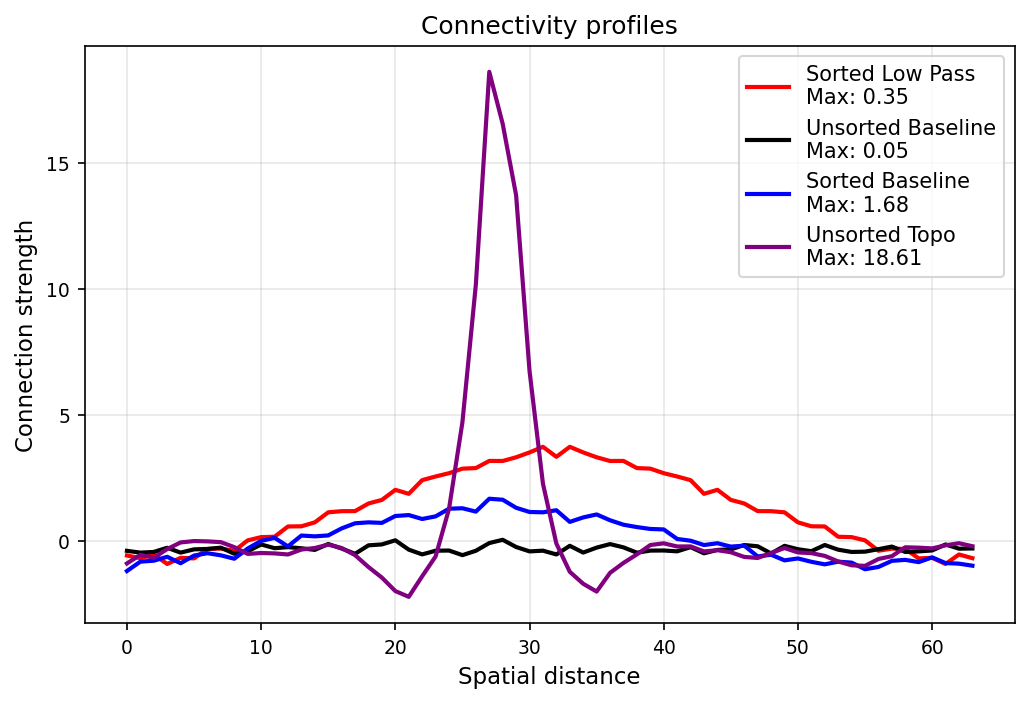

In [12]:
mid = n // 2
slice_sorted_lp = Jmean_lp_sorted[mid, :]
slice_unsorted_base = baseline_imroll_unsorted[mid, :]
slice_sorted_base = baseline_imroll_sorted[mid, :]
slice_unsorted_topo = topo_imroll_unsorted[mid, :]

plt.figure(figsize=(8, 5))
plt.plot(slice_sorted_lp, label=f'Sorted Low Pass\nMax: {slice_unsorted.max():.2f}', color='red', linewidth=2)
plt.plot(slice_unsorted_base, label=f'Unsorted Baseline\nMax: {slice_unsorted_base.max():.2f}', color='black', linewidth=2)
plt.plot(slice_sorted_base, label=f'Sorted Baseline\nMax: {slice_sorted_base.max():.2f}', color='blue', linewidth=2)
plt.plot(slice_unsorted_topo, label=f'Unsorted Topo\nMax: {slice_unsorted_topo.max():.2f}', color='purple', linewidth=2)

plt.title('Connectivity profiles')
plt.xlabel('Spatial distance')
plt.ylabel('Connection strength')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()